# Model

Plan: logistic regression baseline first, then random forest and xgboost. Stratified 80/20 split, all tuning by 5-fold CV inside the training set, and the test set gets touched exactly once at the end.

Class weights for the 80/20 imbalance, not SMOTE. Interpolating one-hot dummies manufactures impossible customers (0.3 German, half active) and distorts the probability scale, and the cost analysis at the bottom needs sane probabilities.

In [1]:
import sqlite3
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")
from features import build_features

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV,
    cross_validate, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from xgboost import XGBClassifier

con = sqlite3.connect("../churn.db")
df = pd.read_sql("select * from customers", con)

X, y = build_features(df)
print(X.shape)
list(X.columns)

(10000, 18)


['credit_score',
 'age',
 'tenure',
 'balance',
 'num_products',
 'has_cr_card',
 'is_active',
 'salary',
 'zero_balance',
 'inactive_50plus',
 'germany_inactive',
 'geography_Germany',
 'geography_Spain',
 'gender_Male',
 'age_band_30-39',
 'age_band_40-49',
 'age_band_50-59',
 'age_band_60+']

18 features. Raw age stays in alongside the bands - the trees can use the continuous version, logistic regression leans on the bands (churn by age is not monotonic, see the EDA).

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

cv = StratifiedKFold(5, shuffle=True, random_state=42)
print(f"train {len(X_train)} @ {y_train.mean():.1%} churn, test {len(X_test)} @ {y_test.mean():.1%}")

train 8000 @ 20.4% churn, test 2000 @ 20.3%


## Baseline: logistic regression

Scoring everything on average precision (PR AUC) rather than ROC AUC. With 20% positives, ROC AUC gets flattered by the easy majority class; PR AUC only cares how well we rank churners, and ranking is all I need from the model since the operating threshold comes from the cost curve below, not from the model.

In [3]:
def cv_scores(model):
    s = cross_validate(model, X_train, y_train, cv=cv,
                       scoring=["roc_auc", "average_precision"], n_jobs=-1)
    return {"roc_auc": round(s["test_roc_auc"].mean(), 3),
            "pr_auc": round(s["test_average_precision"].mean(), 3)}

lr = make_pipeline(StandardScaler(),
                   LogisticRegression(class_weight="balanced", max_iter=1000))
lr_grid = GridSearchCV(lr, {"logisticregression__C": [0.01, 0.1, 1, 10]},
                       cv=cv, scoring="average_precision", n_jobs=-1)
lr_grid.fit(X_train, y_train)

scores = {"logistic": cv_scores(lr_grid.best_estimator_)}
print("C =", lr_grid.best_params_["logisticregression__C"], scores["logistic"])

C = 10 {'roc_auc': np.float64(0.791), 'pr_auc': np.float64(0.559)}


PR AUC 0.559, ROC 0.79. Regularization barely matters (C=10 wins but the grid is nearly flat). Decent floor to beat.

## Random forest and xgboost

Randomized search over a modest space, 5-fold CV, same PR AUC scoring. Small data, so no point in a huge search - 20-30 candidates covers the shapes that matter (tree depth, leaf size, learning rate).

In [4]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    {"n_estimators": [300, 500],
     "max_depth": [None, 8, 12, 16],
     "min_samples_leaf": [1, 2, 5, 10, 20],
     "max_features": ["sqrt", 0.5]},
    n_iter=20, cv=cv, scoring="average_precision", random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

scores["rf"] = cv_scores(rf_search.best_estimator_)
print(rf_search.best_params_, scores["rf"])

{'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 12} {'roc_auc': np.float64(0.854), 'pr_auc': np.float64(0.675)}


In [5]:
spw = (y_train == 0).sum() / (y_train == 1).sum()  # xgboost's version of class weights

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", random_state=42),
    {"n_estimators": [200, 300, 400, 600],
     "learning_rate": [0.03, 0.05, 0.1],
     "max_depth": [3, 4, 5, 6],
     "subsample": [0.7, 0.85, 1.0],
     "colsample_bytree": [0.7, 0.85, 1.0],
     "min_child_weight": [1, 5, 10]},
    n_iter=30, cv=cv, scoring="average_precision", random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

scores["xgb"] = cv_scores(xgb_search.best_estimator_)
print(xgb_search.best_params_, scores["xgb"])

{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7} {'roc_auc': np.float64(0.858), 'pr_auc': np.float64(0.693)}


In [6]:
pd.DataFrame(scores).T

,roc_auc,pr_auc
logistic,0.791,0.559
rf,0.854,0.675
xgb,0.858,0.693


xgboost wins on both metrics (PR AUC 0.693 vs 0.675 for the forest, ROC 0.858 vs 0.854). The search settled on shallow-ish trees (depth 5), a slow learning rate and heavy min_child_weight, which is what usually wins on tabular data this size. Going with xgboost.

## Threshold: where do we actually cut?

Assumptions, not data - ballpark figures for a European retail bank:

- a retention offer costs **30 EUR** per customer contacted (fee waiver, rate bonus, staff time)
- a retained customer is worth **250 EUR/year** in margin
- **30%** of true churners we contact actually take the offer and stay

So a contacted churner is worth 0.3 x 250 = 75 EUR in expectation against 30 spent, and break-even precision is 30/75 = 40%. Below that we lose money on every batch of offers.

The curve is built on cross-validated train predictions. Test set stays in the drawer.

In [7]:
offer_cost, margin, save_rate = 30, 250, 0.30

probs = cross_val_predict(xgb_search.best_estimator_, X_train, y_train,
                          cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

rows = []
for thr in np.arange(0.05, 0.96, 0.01):
    pred = probs >= thr
    tp = (pred & (y_train == 1)).sum()
    fp = (pred & (y_train == 0)).sum()
    fn = (~pred & (y_train == 1)).sum()
    savings = tp * save_rate * margin - (tp + fp) * offer_cost
    rows.append((thr, tp, fp, fn, savings))

cost_curve = pd.DataFrame(rows, columns=["thr", "tp", "fp", "fn", "savings"])
best = cost_curve.loc[cost_curve.savings.idxmax()]
thr = round(best.thr, 2)
print(f"best threshold {thr}, cv savings {best.savings:,.0f} EUR on {len(X_train)} customers")
print(f"precision {best.tp / (best.tp + best.fp):.3f}, recall {best.tp / (best.tp + best.fn):.3f}")

best threshold 0.73, cv savings 27,735 EUR on 8000 customers
precision 0.722, recall 0.509


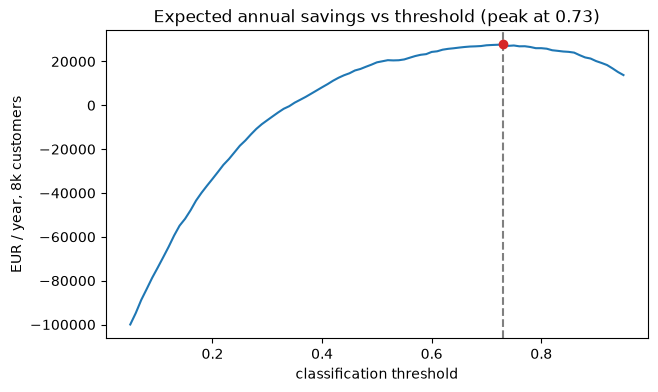

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(cost_curve.thr, cost_curve.savings)
plt.axvline(thr, ls="--", c="gray")
plt.scatter([thr], [best.savings], zorder=3, c="tab:red")
plt.title(f"Expected annual savings vs threshold (peak at {thr})")
plt.xlabel("classification threshold")
plt.ylabel("EUR / year, 8k customers")
plt.savefig("../figures/cost_curve.png", dpi=150, bbox_inches="tight")

Savings peak at **0.73**: about 27.7k EUR/year on the 8,000 training customers, contacting at 72% precision and 51% recall. A threshold of 0.73 sounds absurdly conservative, but these aren't real probabilities - scale_pos_weight inflates the scores, so the cutoff lands high. Below ~0.4 we spray 30 EUR offers at stayers and the margin dies; past ~0.9 we contact almost nobody. The peak is fairly flat between 0.6 and 0.8, which is comforting - the decision doesn't hinge on the third decimal of anyone's assumptions.

## Final numbers - one look at the test set

In [9]:
model = xgb_search.best_estimator_
model.fit(X_train, y_train)
test_probs = model.predict_proba(X_test)[:, 1]

print(f"roc auc {roc_auc_score(y_test, test_probs):.3f}")
print(f"pr auc  {average_precision_score(y_test, test_probs):.3f}")

pred = test_probs >= thr
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"\nat threshold {thr}: contact {tp + fp} of {len(y_test)}")
print(f"tp {tp}  fp {fp}  fn {fn}  tn {tn}")
print(f"precision {tp / (tp + fp):.3f}, recall {tp / (tp + fn):.3f}")
print(f"expected net savings {tp * save_rate * margin - (tp + fp) * offer_cost:,.0f} EUR on the 2,000-customer test slice")

roc auc 0.887
pr auc  0.743

at threshold 0.73: contact 317 of 2000
tp 230  fp 87  fn 177  tn 1506
precision 0.726, recall 0.565
expected net savings 7,740 EUR on the 2,000-customer test slice


ROC AUC **0.887**, PR AUC **0.743** - a notch above the CV numbers, which is partly the refit on all 8k rows and partly luck of the split. At the 0.73 threshold the model flags 317 of 2,000 test customers and 230 are real churners: **73% precision, 57% recall**, expected net savings **7.7k EUR** on the test slice, or roughly **39k EUR/year scaled to the full 10k book**. All downstream of the cost assumptions above, but the ranking (and therefore the shape of the curve) is not.

## What drives it

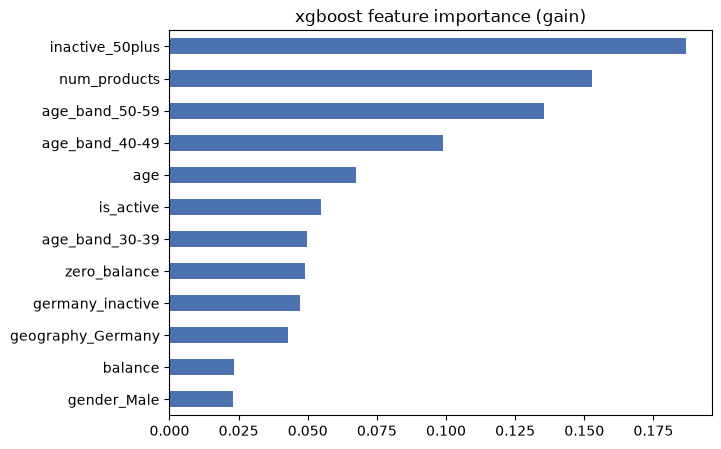

In [10]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
feat_imp.tail(12).plot.barh(color="#4c72b0")
plt.title("xgboost feature importance (gain)")
plt.savefig("../figures/feat_imp.png", dpi=150, bbox_inches="tight")

The engineered flags earn their keep: `inactive_50plus` is the top feature, `num_products` and the 50-59 age band follow, and `germany_inactive` beats plain `geography_Germany`. Tenure and salary are nowhere, matching the EDA.

## What the bank should do with this

1. **Call the inactive 50+ book first.** The single strongest churn signal, and the EDA says these customers leave at 81-86%. They are also disproportionately funded. A re-engagement contact program here is where the model earns its money.
2. **Treat Germany as a product/pricing problem, not a marketing problem.** Even active German customers churn above the whole-book base rate, so this is not disengagement. Something about the German offering (pricing, competition, product fit) needs a proper review.
3. **Pull apart the 3-4 product bundles.** 83-100% churn among holders. That pattern smells like fee stacking or aggressive cross-selling. Small group (326 customers), near-certain loss.
4. **Test moving funded single-product customers to a second product.** Two products is the churn sweet spot (7.6% vs 27.7% for one). That's correlation, not causation - which is exactly why it's framed as the experiment in notebook 03 rather than a rollout.